![Banner](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/prompt_engineering_banner.jpg)


# The Road to Agency: How Prompts Work

# Introduction

We hear the term prompt engineering often, and most of us do it unconsciously when we talk to ChatGPT or Claude. But prompting has much more depth than it first appears. To understand conditioning, in-context learning (ICL), chain-of-thought (CoT), and self-consistency, we need to understand how the underlying LLM is being conditioned.

This is the second article in the series "The Road to Agency", with the [previous article](https://medium.com/call-for-atlas/the-road-to-agency-how-large-language-models-work-94d9907b03af) walking through LLM internals from text to next-token probabilities. Once that architecture is in place, the next question is natural: how does a prompt steer the reply? Why does adding "Let's think step by step" sometimes change the answer? Why can three examples in the context teach the model a new task without altering a single parameter?

That is the question this notebook answers.

## Notebook Setup

You'll need PyTorch, Hugging Face Transformers, and the usual numerical and plotting stack. The first time you run the notebook, SmolLM2 has to be downloaded, so the initial load is slower than later runs. Everything runs on CPU, so you do not need to worry about CUDA for a first pass.

**NB:** This notebook was tested with **Transformers 5.6.2**. If you are using an older Transformers release, use `torch_dtype=torch.float32` instead.

In [1]:
# Optional environment bootstrap for a fresh Kaggle or Colab session.
# If you already created the environment from requirements.txt or environment.yml, skip this cell.
# %pip install torch transformers numpy pandas matplotlib seaborn scikit-learn


In [2]:
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers as _tf
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}  |  Transformers {_tf.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


PyTorch 2.11.0+cpu  |  Transformers 5.6.2
Device: cpu


## Loading a Small Base Model

Like the previous article, we will use the base version of **SmolLM2-135M**. This model is not instruction-tuned in the same way as the instruct variant, which makes it a better candidate for studying raw next-token conditioning. It is still a modern pretrained model trained on curated mixtures of web, maths, code, and specialised data.

In [3]:
BASE_ID = "HuggingFaceTB/SmolLM2-135M"

tokenizer = AutoTokenizer.from_pretrained(BASE_ID)
model_base = AutoModelForCausalLM.from_pretrained(
    BASE_ID,
    dtype=torch.float32,
    attn_implementation="eager",
)
model_base.eval()
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Base model parameters: {sum(p.numel() for p in model_base.parameters()):,}")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Tokenizer vocab size: 49,152
Base model parameters: 134,515,008


# How a Prompt Changes the Distribution

An autoregressive LLM generates text one token at a time.

If the output tokens are: $y_1, y_2, \dots, y_T$.

then the model assigns probability to the whole sequence by multiplying many next-token probabilities:

$$
P(y_1, y_2, \dots, y_T) = \prod_{t=1}^{T} P(y_t \mid y_{<t})
$$

Here, $y_t$ means the token at position $t$, and $y_{<t}$ means all tokens before position $t$.

So this formula says:

1. predict $y_1$.  
2. predict $y_2$ given $y_1$.  
3. predict $y_3$ given $y_1, y_2$.  
4. Continue until the sequence is complete.

Now suppose we give the model a prompt: $x = (x_1, x_2, \dots, x_n)$. The generated output is no longer just a free continuation. It is a continuation conditioned on the prompt:

$$
P(y_1,\dots,y_T \mid x) = \prod_{t=1}^{T} P(y_t \mid x, y_{<t})
$$

This means every generated token depends on the prompt tokens and on the tokens already generated. Written out more explicitly:

$$
P(y_t \mid x_1,\dots,x_n,y_1,\dots,y_{t-1})
$$

The prompt is not metadata. It is not a hidden command channel. It is just more text in the sequence.

Inside the transformer, the prompt tokens affect the hidden states. Those hidden states produce logits. The logits become probabilities over the next token. So when we change the prompt, we change the probability distribution the model samples from. A prompt does not mechanically command the model. It changes which continuations become more likely.

For a base model, this may simply mean continuing the style or pattern of the prompt. For an instruction-tuned model, instructions work better because the model has been trained to make instruction-following continuations likely.

So we can describe prompt engineering as the craft of reshaping: $P(y \mid x)$,

Therefore the goal is to choose the prompt $x$ so that the model's high-probability completions match the behavior we want.

## How Those Tokens Reach the Reply

Now we can connect the probability view to what happens inside the model.

Suppose the prompt is:

$$
x = (x_1, x_2, \dots, x_n)
$$

The model reads these prompt tokens and produces a hidden vector at each position.

At the final prompt position, the top-layer hidden vector is: $h_n^{(L)}$. Here, $h_n^{(L)}$ means the hidden vector at position $n$ after layer $L$, the final transformer layer.

This vector is the model's contextual representation of the prompt so far. It contains information from the prompt tokens that the final position is allowed to attend to.

To predict the next token, the model passes this hidden vector through the language-model head, usually called the LM head:

$$
z_{n+1} = W_{\mathrm{LM}} h_n^{(L)} + b
$$

Here, $W_{\mathrm{LM}}$ is a learned weight matrix, $b$ is a learned bias term, and $z_{n+1}$ is the vector of logits for the next token. As we previously learned, a logit is an unnormalized score. There is one logit for each token in the vocabulary.The logits are then converted into probabilities using softmax:

$$
P(y_1 \mid x) = \mathrm{softmax}(z_{n+1})
$$

This gives the probability distribution over the first generated token $y_1$. So the next-token decision is read from the last position of the current prefix.

After the model chooses a token, that token is appended to the sequence. The prefix becomes: $(x_1, x_2, \dots, x_n, y_1)$. Now the model predicts the next generated token:

$$
P(y_2 \mid x_1,\dots,x_n,y_1)
$$

Then it appends $y_2$ and predicts $y_3$:

$$
P(y_3 \mid x_1,\dots,x_n,y_1,y_2)
$$

This repeats until generation stops. From what we learned in our first article, models do not usually recompute everything from scratch at every step. They cache key-value states from earlier tokens in a KV cache.

That is why prompt tokens shape the reply. They affect the hidden states of the prefix. Those hidden states affect the logits. The logits affect the next-token probabilities. And every generated token becomes part of the prefix for the next step.

Prompt: A prompt changes the model because
Prompt tokens: ['A', 'Ġprompt', 'Ġchanges', 'Ġthe', 'Ġmodel', 'Ġbecause']
Prompt length: 6 tokens
Final hidden vector shape h_n: (576,)
Logits shape z_next: (49152,)
Probability vector shape: (49152,)

 rank  token_id  token  probability
    1       357    Ġit     0.301896
    2       260   Ġthe     0.211321
    3       282    Ġof     0.121923
    4       346   Ġyou     0.046401
    5       253     Ġa     0.038481
    6       392    Ġwe     0.020127
    7       384    Ġhe     0.019378
    8       665 Ġthere     0.016483
    9       502  Ġthey     0.014039
   10       198      Ċ     0.011700


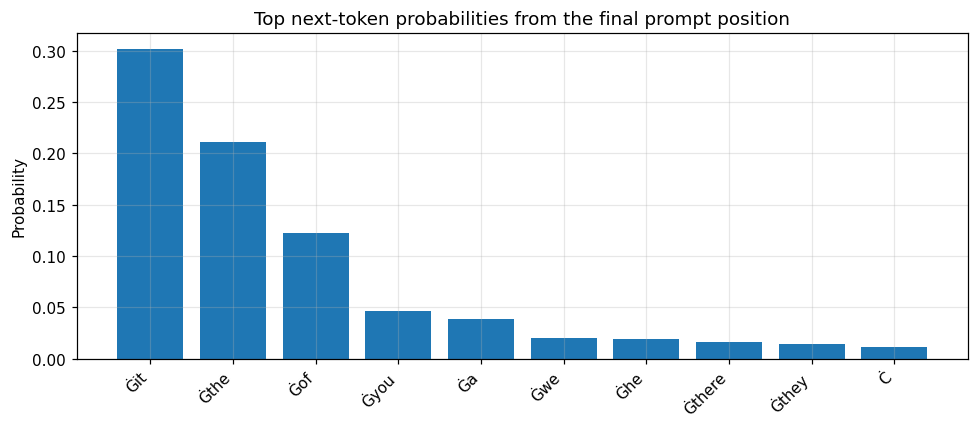

In [4]:
prompt = "A prompt changes the model because"

inputs = tokenizer(prompt, return_tensors="pt")
input_ids = inputs["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

with torch.no_grad():
    outputs = model_base(input_ids=input_ids, output_hidden_states=True)

h_n = outputs.hidden_states[-1][0, -1]
logits = outputs.logits[0, -1]
probs = torch.softmax(logits, dim=-1)

top_k = 10
top_probs, top_ids = torch.topk(probs, top_k)
top_tokens = tokenizer.convert_ids_to_tokens(top_ids.tolist())

df = pd.DataFrame(
    {
        "rank": range(1, top_k + 1),
        "token_id": top_ids.tolist(),
        "token": top_tokens,
        "probability": top_probs.tolist(),
    }
)

print(f"Prompt: {prompt}")
print(f"Prompt tokens: {tokens}")
print(f"Prompt length: {input_ids.shape[1]} tokens")
print(f"Final hidden vector shape h_n: {tuple(h_n.shape)}")
print(f"Logits shape z_next: {tuple(logits.shape)}")
print(f"Probability vector shape: {tuple(probs.shape)}")
print()
print(df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.bar(df["token"], df["probability"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Probability")
plt.title("Top next-token probabilities from the final prompt position")
plt.tight_layout()
plt.show()


## Prompts Change the Next Token

We feed SmolLM2 different prompts that all end at the same decision point, and compare the resulting next-token distributions. This makes the conditioning effect visible.

=== How Prompts Seed the Reply ===

Neutral
  Prompt: 'The answer is'
  Token count: 3
  Final hidden vector h_n shape: (576,)
  Next-token logits shape: (49152,)
  Top next tokens:
         ' that'  0.1304
               ,  0.0891
               :  0.0567
          ' yes'  0.0508
           ' no'  0.0393

Math
  Prompt: 'What is 12 + 7? The answer is'
  Token count: 12
  Final hidden vector h_n shape: (576,)
  Next-token logits shape: (49152,)
  Top next tokens:
             ' '  0.6536
               :  0.0654
            ' ('  0.0212
               ,  0.0212
            ' "'  0.0148

Geography
  Prompt: 'What is the capital of Japan? The answer is'
  Token count: 10
  Final hidden vector h_n shape: (576,)
  Next-token logits shape: (49152,)
  Top next tokens:
        ' Tokyo'  0.0958
               :  0.0899
          ' the'  0.0537
        ' Japan'  0.0371
               ,  0.0269

Negative
  Prompt: 'The movie was terrible. The review said the answer is'
  Token count: 11
  Final 

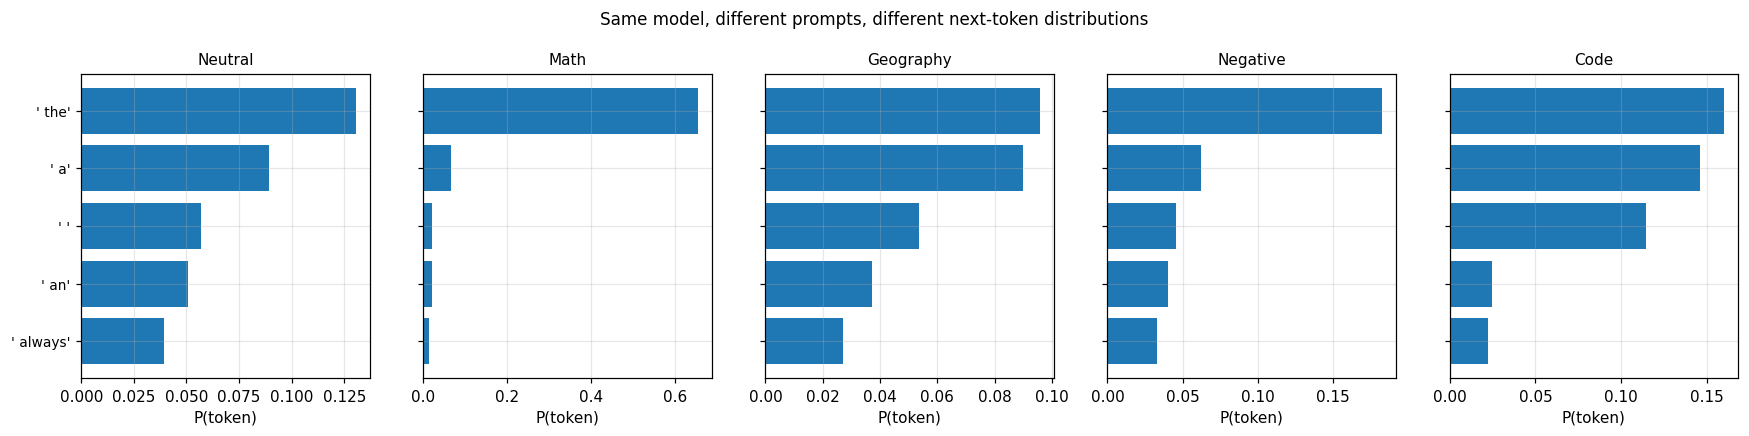

In [5]:
prompts = {
    "Neutral": "The answer is",
    "Math": "What is 12 + 7? The answer is",
    "Geography": "What is the capital of Japan? The answer is",
    "Negative": "The movie was terrible. The review said the answer is",
    "Code": "def add(a, b): return a + b  # The answer is",
}


def token_label(token_id):
    token_text = tokenizer.decode([token_id])
    if token_text.strip() == "":
        return repr(token_text)
    if token_text.startswith(" ") or token_text.endswith(" ") or "\n" in token_text:
        return repr(token_text)
    return token_text


print("=== How Prompts Seed the Reply ===\n")

all_top5 = {}

for label, prompt in prompts.items():
    ids = tokenizer.encode(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model_base(ids, output_hidden_states=True)

    h_last = outputs.hidden_states[-1][0, -1]
    logits = outputs.logits[0, -1].float()
    probs = torch.softmax(logits, dim=-1)

    top5_probs, top5_ids = torch.topk(probs, 5)
    top5 = [(token_label(tok_id.item()), prob.item()) for tok_id, prob in zip(top5_ids, top5_probs)]

    all_top5[label] = {
        "prompt": prompt,
        "tokens": tokenizer.convert_ids_to_tokens(ids[0]),
        "n_tokens": ids.shape[1],
        "hidden_shape": tuple(h_last.shape),
        "logits_shape": tuple(logits.shape),
        "top5": top5,
    }

    print(f"{label}")
    print(f"  Prompt: {prompt!r}")
    print(f"  Token count: {ids.shape[1]}")
    print(f"  Final hidden vector h_n shape: {tuple(h_last.shape)}")
    print(f"  Next-token logits shape: {tuple(logits.shape)}")
    print("  Top next tokens:")
    for tok, p in top5:
        print(f"    {tok:>12s}  {p:.4f}")
    print()

fig, axes = plt.subplots(1, len(prompts), figsize=(16, 4), sharey=True)

for ax, (label, result) in zip(axes, all_top5.items()):
    tokens, probs_list = zip(*result["top5"])
    ax.barh(range(5), probs_list)
    ax.set_yticks(range(5))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("P(token)")
    ax.set_title(label, fontsize=10)

fig.suptitle("Same model, different prompts, different next-token distributions", fontsize=11)
plt.tight_layout()
plt.show()


The output shows the exact mechanism we just described.

The model is unchanged across all five examples. Same weights, same vocabulary, same LM head. The only thing that changes is the prompt. Yet the next-token distribution changes sharply.

For the neutral prompt, `"The answer is"`, the model has no clear task. It spreads probability across generic continuations such as `' that'`, punctuation, `' yes'`, and `' no'`. This is what uncertainty looks like when the context is underspecified.

For the math prompt, `"What is 12 + 7? The answer is"`, the top token is a space with probability about `0.65`. That does not mean the model has answered the question yet. It means the model first wants to emit a formatting token before the answer. If we generated one or two more tokens, we would see whether it moves toward `19`. This is a useful tokenizer lesson: the next token is not always the semantic answer. Sometimes it's whitespace, punctuation, or formatting.

For the geography prompt, the distribution moves toward `' Tokyo'`. This is the clearest case. The prompt creates a context where `Tokyo` becomes a high-probability continuation. The model has not been fine-tuned between examples. The prompt alone made that continuation more likely.

For the negative movie-review prompt, the model predicts quote-like tokens such as `' "'` and `' “'`. This makes sense because the phrase `"The review said the answer is"` sounds like the start of quoted text. The model is continuing the local pattern, not solving a factual task.

For the code prompt, the distribution shifts again. Tokens like `' the'`, `' a'`, and whitespace dominate. The Python context changes the hidden state, but the final phrase `# The answer is` is inside a comment, so the model is likely continuing explanatory comment text rather than doing arithmetic.

The shapes connect the plot to the model internals:

- `h_n` has shape `(576,)`, so SmolLM2-135M represents the final prompt position with a 576-dimensional contextual vector.
- The logits have shape `(49152,)`, one score for each vocabulary token.
- Softmax turns those 49,152 logits into the next-token probability distribution shown in the plots.

The prompt changes the final hidden vector. The hidden vector changes the logits. The logits change the probability distribution over the next token:

```mermaid
flowchart LR
    A["Prompt<br/>x = (x₁, ..., xₙ)"]
    B["Transformer processes the prompt"]
    C["Final prompt representation<br/>hₙ^(L)"]
    D["LM head produces logits<br/>zₙ₊₁ = W_LM hₙ^(L) + b"]
    E["Softmax turns logits into probabilities<br/>P(y₁ | x)"]
    F["Model picks the next token<br/>y₁"]

    A --> B --> C --> D --> E --> F
```

# Raw Prompts, Roles, and Chat Templates

So far we have used raw completion prompts because they expose the conditioning story cleanly. We give the model a prefix, then inspect how the next-token distribution moves.

Most deployed chat models wrap inputs in a chat template before decoding. A conversation with system, developer, user, and assistant roles is serialized into a model-specific token sequence, for example:

```text
<|system|> You are a careful tutor.
<|user|> Explain value at risk in one paragraph.
<|assistant|>
```

The exact markers vary across model families. The important point is that the roles are not magic. They are tokens inserted by the template, and post-training teaches the model to treat those role markers differently. Mechanistically, chat prompting is still next-token conditioning over a longer prefix.

# Learning from Examples - or - Changing the Weights

Once prompt conditioning is clear, in-context learning becomes much easier to understand. The point is not just that we give the model an instruction. We also give it a few worked examples inside the prompt. The model then uses those examples as context when producing the reply.

Brown et al. (2020) showed that large language models can often infer a task at inference time from examples placed directly in the prompt. For example:

```text
Translate English to French:
cat → chat
dog → chien
house →
```

A strong enough model will often continue with `maison`.

What matters here is that nothing in the model's weights has changed. There is no gradient update and no retraining step. The examples are not being learned in the usual training sense. They are simply extra tokens in the current context window.

Suppose we provide $k$ examples, written as input-output pairs $(x_1, y_1), \dots, (x_k, y_k)$, followed by a new query $x_{\text{query}}$.

Then the model is conditioned to produce an answer from a conditional distribution of the form

$$
P\!\left(y \mid x_1, y_1, \dots, x_k, y_k, x_{\text{query}}\right).
$$

Here, $y$ is the model's answer to the query $x_{\text{query}}$. The earlier example pairs are just part of the prompt. This formula says that the model conditions its answer on all of that context. In effect, the model is asking: *given these examples and this new input, what continuation now looks most likely?*

That is why ICL is best viewed as a special case of prompt conditioning. The examples do not update the model. They reshape the distribution over completions for this one conversation.



```mermaid
flowchart LR
    A["Examples in the prompt<br/>(x₁,y₁), ..., (xₖ,yₖ)"]
    B["New query<br/>x_query"]
    C["Transformer context"]
    D["Next-token distribution<br/>P(y | examples, x_query)"]
    E["Answer<br/>y"]

    A --> C
    B --> C
    C --> D --> E
```


The examples and the query enter the same context window. The model does not treat the examples as a training set. It treats them as previous text that helps determine the next likely continuation. Attention here lets the model scan the prompt for local patterns.

If the prompt contains examples like this:

```text
cat → chat
dog → chien
house →
```

then the model can notice that the pattern looks like a translation task. The new query, `house`, resembles the earlier inputs, and the earlier outputs show the kind of continuation that should follow.

So the model does something like this:

1. It identifies the pattern in the prompt.
2. It recognizes that the new query fits that pattern.
3. It continues in the same format.

This is not the same as saying the model has discovered a full symbolic algorithm for translation inside the prompt. It may simply be very good at pattern completion in context.

Mechanistic interpretability work gives some support to this picture. Olsson et al. (2022) describe induction-head behaviour, where some attention heads appear to support a kind of copy-and-continue mechanism.

Roughly speaking, these heads help the model notice that a current token sequence resembles something seen earlier in the prompt, and then continue in a similar way.

That said, induction heads are only part of the story. They help explain some ICL behaviour, especially copying, repetition, and local continuation patterns. They are not a complete explanation of all ICL, especially on tasks where the model seems to infer a higher-level task structure rather than just copying a nearby pattern.

The number of examples matters, but only up to a point.

**Zero-shot** means we give only an instruction, with no examples. For modern instruction-tuned models, this is often enough for common tasks.

```text
Translate English to French: house
```

**Few-shot** usually means around 1 to 5 examples. This often gives a large boost when the task format is clear and the examples are good.

```text
Translate English to French:
cat → chat
dog → chien
house →
```

**Many-shot** might mean 10 to 50 examples, or sometimes more. This can help, but the gains are often smaller. It also uses more of the context window, increases cost, and can even hurt performance if the prompt becomes noisy or inconsistent.

More examples are not automatically better. Quality, consistency, and formatting usually matter more than sheer count.

ICL is powerful, but it is also fragile. Small changes in formatting can matter. Label names can matter. The order of examples can matter. Even spacing or punctuation can matter. If the prompt changes, the hidden states change. If the hidden states change, the next-token distribution changes. So prompt-based learning is flexible, but it is not always stable.

## Changing the weights instead

Unlike ICL, fine-tuning solves a different problem. Instead of giving the model temporary structure through the prompt, we update the model parameters themselves. Let $\theta$ denote the model weights, and let $\mathcal{D}$ be a task-specific dataset of input-output pairs $(x,y)$.

A standard fine-tuning objective is

$$
\theta^* = \arg\min_{\theta} \sum_{(x,y) \in \mathcal{D}} -\log P_\theta(y \mid x).
$$

Here, $\theta^*$ means the updated weights after fine-tuning. The term $P_\theta(y \mid x)$ is the probability that the model with weights $\theta$ assigns to the target answer $y$ given the input $x$.

The expression $-\log P_\theta(y \mid x)$ is the loss. It is small when the model assigns high probability to the correct answer, and large when the model assigns low probability to the correct answer.

So this formula says: choose the weights that make the correct answers in the dataset as likely as possible. Fine-tuning changes the model so that useful task-specific behaviour becomes part of the parameters themselves.

In ICL, the task information lives in the prompt. In fine-tuning, the task information is baked into the weights. Because of that, fine-tuning changes the model's behaviour for future inputs even when the prompt is short. The table below compares the two approaches:

| Aspect | In-context learning | Fine-tuning |
|---|---|---|
| What changes | The prompt, which is part of the input | The weights $\theta$ |
| When it happens | At inference time | During training |
| Persistence | Temporary, only for the current conversation or prompt | Persistent across future uses of the tuned model |
| Data needed | Often 0 to 50 examples in the prompt | Usually from dozens to many thousands of labeled examples, depending on the task and quality target |
| Prompt cost at runtime | Uses context-window space and adds token cost | Can reduce prompt length, though inference still costs compute |
| Generalization | Flexible, but often brittle to wording and format | Usually more stable on the training distribution, but still limited by data quality and distribution shift |
| Up-front cost | Cheap to try | More expensive because training requires compute and workflow overhead |

Use ICL when you only have a few examples, when you want to switch tasks quickly, or when the task is simple enough that a good prompt is likely to work.
Use fine-tuning when you have labeled data, need more consistent behaviour, or care about a narrow task where prompting alone is too unreliable.

You can use both when you want the benefits of a specialised model but still want some runtime control. For example, you might fine-tune a model for a domain, then still use a short prompt with a couple of examples to specify the exact format you want today.

The code below puts that distinction into a small sentiment task. We report mean log-probability per token because the label candidates are equal or near-equal length here. Total log-probability is the true continuation score. Mean log-probability is a length-normalised diagnostic.

=== In-Context Learning: Zero-Shot vs Few-Shot ===

Zero-shot
Prompt length: 23 tokens
   label  total_logprob  mean_logprob  tokens
positive      -4.605263     -4.605263       1
negative      -4.746151     -4.746151       1
 neutral      -7.519616     -7.519616       1

Few-shot
Prompt length: 63 tokens
   label  total_logprob  mean_logprob  tokens
negative      -0.565545     -0.565545       1
positive      -1.766551     -1.766551       1
 neutral      -3.131243     -3.131243       1



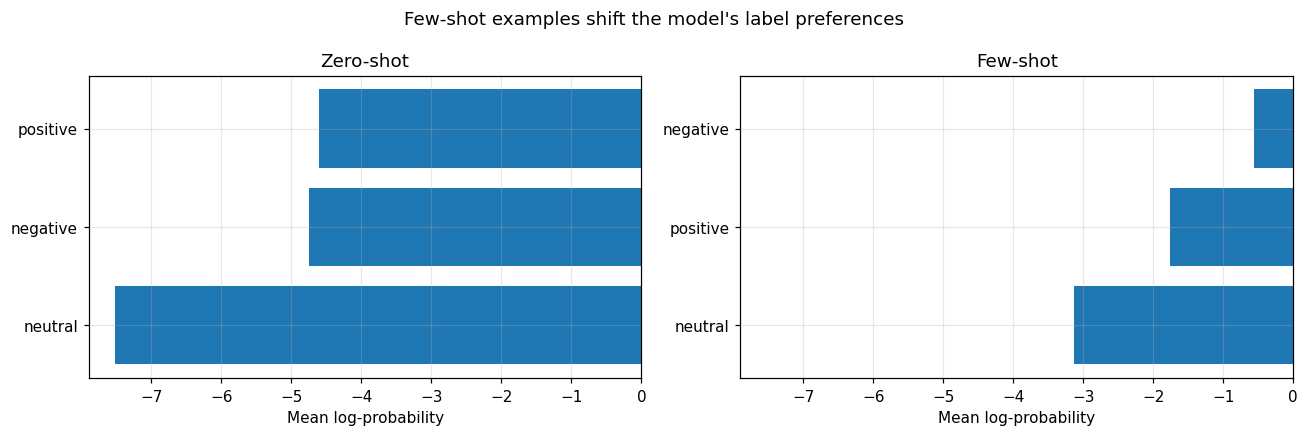

In [6]:
zero_shot_prompt = 'Classify the sentiment as positive or negative.\nText: "The battery life is awful."\nSentiment:'
few_shot_prompt = (
    "Classify the sentiment as positive or negative.\n"
    'Text: "I love this phone!" Sentiment: positive\n'
    'Text: "Worst purchase ever." Sentiment: negative\n'
    'Text: "Amazing camera quality." Sentiment: positive\n'
    'Text: "The battery life is awful."\nSentiment:'
)

candidate_labels = [" positive", " negative", " neutral"]


def continuation_logprob(prompt_text, continuation_text):
    prompt_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    continuation_ids = tokenizer.encode(continuation_text, add_special_tokens=False)
    full_ids = torch.tensor([prompt_ids + continuation_ids])
    with torch.no_grad():
        logits = model_base(full_ids).logits[0]
    log_probs = []
    start = len(prompt_ids)
    for pos, tok_id in enumerate(continuation_ids, start=start):
        token_logprob = torch.log_softmax(logits[pos - 1], dim=-1)[tok_id].item()
        log_probs.append(token_logprob)
    total_lp = float(np.sum(log_probs))
    mean_lp = total_lp / len(continuation_ids)
    return total_lp, mean_lp, continuation_ids


print("=== In-Context Learning: Zero-Shot vs Few-Shot ===\n")

results = {}

for name, prompt in {
    "Zero-shot": zero_shot_prompt,
    "Few-shot": few_shot_prompt,
}.items():
    rows = []
    for candidate in candidate_labels:
        total_lp, mean_lp, ids = continuation_logprob(prompt, candidate)
        rows.append(
            {
                "label": candidate.strip(),
                "total_logprob": total_lp,
                "mean_logprob": mean_lp,
                "tokens": len(ids),
            }
        )
    df = pd.DataFrame(rows).sort_values("mean_logprob", ascending=False)
    results[name] = df

    prompt_ids = tokenizer.encode(prompt, return_tensors="pt")
    print(name)
    print(f"Prompt length: {prompt_ids.shape[1]} tokens")
    print(df.to_string(index=False))
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, (name, df) in zip(axes, results.items()):
    ax.barh(df["label"], df["mean_logprob"])
    ax.invert_yaxis()
    ax.set_title(name)
    ax.set_xlabel("Mean log-probability")

fig.suptitle("Few-shot examples shift the model's label preferences")
plt.tight_layout()
plt.show()

From the code's output we see that in the zero-shot prompt, the model only sees the instruction and the sentence:

```text
Classify the sentiment as positive or negative.
Text: "The battery life is awful."
Sentiment:
```

The model slightly prefers positive over negative. That is wrong for this sentence, but that is not the main lesson. We are using a small base model, not a sentiment classifier or a strong instruction-tuned model.

After we add three examples, the result changes. The model now gives the highest score to negative, which is the correct label for "The battery life is awful."

The important point is that the model weights did not change. We did not train the model. We did not update its parameters. We only changed the prompt.

The examples gave the model a local pattern:

```text
Text: ... Sentiment: label
Text: ... Sentiment: label
Text: ... Sentiment:
```

The model then continued that pattern for the new sentence.

The scores are log-probabilities. They are negative numbers, so values closer to zero are better. In the few-shot case, negative has a much better score than positive, so the model now prefers the negative label. This is in-context learning. The model is learning from the prompt temporarily, not updating its weights.

# How Reasoning Tokens Help

If prompt tokens can steer the model, then reasoning tokens can do the same thing.

This happens through reasoning traces, which are simply more text in the sequence. Suppose the user asks:

```text
What is 37 × 48?
```

The model might generate:

```text
37 × 48 = 37 × (50 - 2)
37 × 50 = 1850
37 × 2 = 74
1850 - 74 = 1776
```

Each of those generated tokens becomes part of the context for the next token. So later tokens are conditioned on both the original prompt and the reasoning trace:

$$
P(y_T \mid x_1, \dots, x_n, y_1, \dots, y_{T-1})
$$

Here, $x_1,\dots,x_n$ are the prompt tokens, and $y_1,\dots,y_{T-1}$ are the tokens the model has already generated. The model is no longer answering from the original question alone. It is answering from the question plus its own intermediate work.

A CoT trace acts like a scratchpad inside the sequence. It helps in three ways.

1. It breaks a hard problem into smaller pieces. Instead of jumping directly from `37 × 48` to the answer, the model can rewrite the problem as `37 × (50 - 2)`.
2. It stores intermediate results. The model does not have a separate notebook where it can write `1850` and `74`. The only place to store those values is in the generated text itself.
3. It gives the model more inference-time compute. Each new reasoning token creates another decoding step. At each step, the transformer runs again over a richer prefix.

That last point matters. If a model has $N = 30$ layers and generates a $T = 20$ token reasoning trace, it does not become a 600-layer model. It is still a 30-layer model. But it does run those 30 layers across 20 sequential decoding steps. Each step sees more context than the previous one.

Some models are trained to spend more tokens on reasoning before giving a final answer. These are often called reasoning models or thinking models. This does not mean the model has a separate magical thinking module. The basic mechanism is still autoregressive generation. The model generates intermediate tokens, then conditions later tokens on those intermediate tokens.

Different model families handle this differently. Some expose the reasoning trace. Some show only a summary. Some hide the reasoning tokens entirely. Some use a fixed reasoning budget. Others use more tokens when the task looks harder. The important practical point is that reasoning tokens still have a cost. They use time, compute, and usually money, even when the full trace is hidden from the user.

Visible reasoning is not always faithful.

A model can write an explanation that sounds convincing, even if that explanation is not the true reason it produced the answer. So we should not treat every CoT trace as a perfect window into the model's internal computation. Reasoning tokens can help because they create useful intermediate context. But more visible reasoning does not automatically mean more reliable reasoning.

As reasoning tokens accumulate, they become part of the prefix. The model starts with the prompt. It generates intermediate steps. Those steps become context. Later tokens are then predicted from a richer sequence. CoT works when the intermediate text makes better continuations more likely.

The code below uses a worked trace that changes the candidate answer scores. For arithmetic prompts, a raw next-token view is often dominated by whitespace tokens. So here we score a small set of plausible answer continuations with and without an explicit reasoning trace. That makes the downstream effect of CoT much easier to see.

Direct
Prompt: 'What is 12 + 15? The answer is'
    27  total= -2.021  mean= -0.674  tokens=3
    26  total= -2.806  mean= -0.935  tokens=3
    28  total= -2.851  mean= -0.950  tokens=3
    30  total= -4.076  mean= -1.359  tokens=3
    43  total= -7.414  mean= -2.471  tokens=3

With reasoning trace
Prompt: 'What is 12 + 15? Let me think step by step. 12 + 15 = 12 + 10 + 5 = 22 + 5 ='
    27  total= -0.776  mean= -0.259  tokens=3
    26  total= -2.497  mean= -0.832  tokens=3
    28  total= -3.258  mean= -1.086  tokens=3
    30  total=-12.003  mean= -4.001  tokens=3
    43  total=-15.891  mean= -5.297  tokens=3



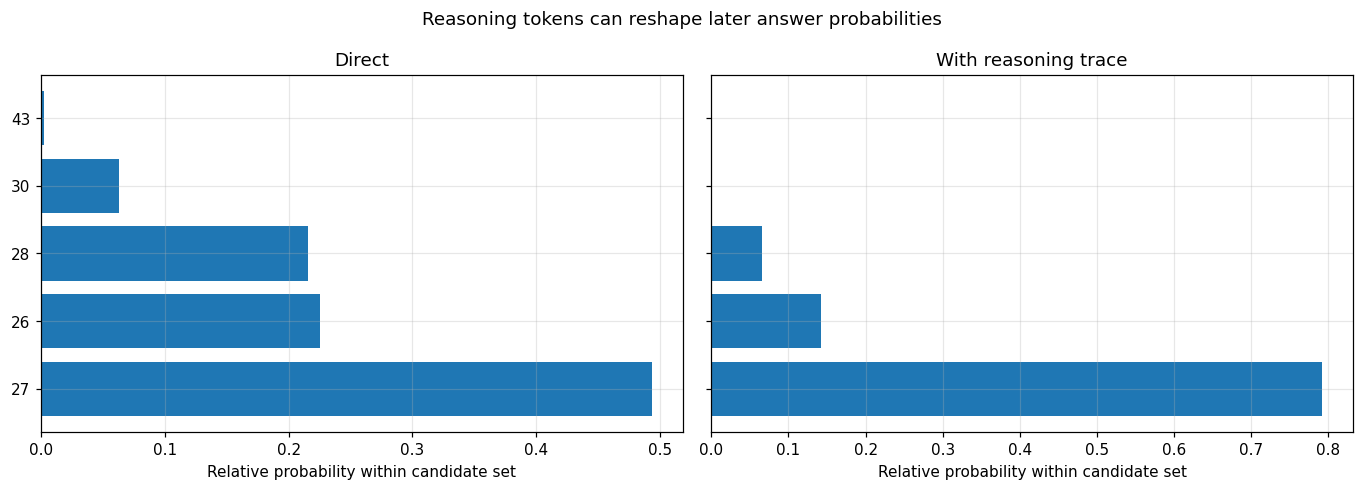

In [7]:
prompt_direct = "What is 12 + 15? The answer is"
prompt_cot = "What is 12 + 15? Let me think step by step. 12 + 15 = 12 + 10 + 5 = 22 + 5 ="
candidate_continuations = [("27", " 27"), ("26", " 26"), ("28", " 28"), ("30", " 30"), ("43", " 43")]

score_tables = {}

for label, prompt in [("Direct", prompt_direct), ("With reasoning trace", prompt_cot)]:
    rows = []
    for answer, continuation in candidate_continuations:
        total_lp, mean_lp, continuation_ids = continuation_logprob(prompt, continuation)
        rows.append((answer, total_lp, mean_lp, len(continuation_ids)))

    score_tables[label] = rows

    print(label)
    print(f"Prompt: {prompt!r}")
    for answer, total_lp, mean_lp, n_tok in rows:
        print(f"  {answer:>4s}  total={total_lp:>7.3f}  mean={mean_lp:>7.3f}  tokens={n_tok}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), sharey=True)

for ax, (label, rows) in zip(axes, score_tables.items()):
    labels_plot = [row[0] for row in rows]
    total_scores = np.array([row[1] for row in rows], dtype=float)
    relative_probs = np.exp(total_scores - total_scores.max())
    relative_probs = relative_probs / relative_probs.sum()

    ax.barh(range(len(labels_plot)), relative_probs)
    ax.set_yticks(range(len(labels_plot)))
    ax.set_yticklabels(labels_plot)
    ax.invert_yaxis()
    ax.set_xlabel("Relative probability within candidate set")
    ax.set_title(label)

fig.suptitle("Reasoning tokens can reshape later answer probabilities")
plt.tight_layout()
plt.show()


Here the model has not simply copied 27 from the prompt. It has to score the possible next continuations after seeing the intermediate work.

In the direct prompt, the model already prefers 27, but not overwhelmingly. Within our candidate set, 26 and 28 still have meaningful probability.

With the reasoning trace, the distribution changes sharply. The score for 27 improves from -2.021 to -0.776. Since log-probabilities are negative, closer to zero is better. The wrong answers also become less competitive, especially 30 and 43.

# Writing Out the Steps

A single forward pass can be too compressed for tasks whose solution is naturally multi-step. Wei et al. (2022) showed that few-shot CoT prompting can improve performance when the model is encouraged to externalise intermediate reasoning. Kojima et al. (2022) then showed that even the short cue "Let's think step by step" can elicit similar behaviour in sufficiently capable models.

The model may generate a trace like:
```
Q: What is 37 × 48?
A: Let me think step by step.
   37 × 48 = 37 × 50 - 37 × 2
           = 1850 - 74
           = 1776.
```

The key mechanism is concrete. Each intermediate token becomes part of the context for the next one, so the model can use its own output as a temporary workspace. Mechanistically, this is not extra depth inside one forward pass. It is repeated use of the same fixed transformer stack across more decoding steps.

The limitation matters just as much. CoT does not guarantee correctness. It can produce a fluent rationale for a wrong answer, and the visible chain may be only a partial or post-hoc explanation of what drove the prediction (Turpin et al., 2023).

# When Several Chains Disagree

Once CoT is available, the next natural question is whether we should trust any single reasoning trace. Often the answer is no. Wang et al. (2022) proposed **self-consistency**: sample multiple full CoT completions, extract the final answer from each, and let agreement carry evidential weight.

1. Sample $N$ CoT completions $c_1, \dots, c_N$ from the model, usually with temperature $\tau > 0$.
2. Extract the final answer from each chain: $a_i = \text{answer}(c_i)$.
3. Take the **majority vote**:

$$
\hat{a} = \arg\max_{a} \sum_{i=1}^{N} \mathbf{1}[\text{answer}(c_i) = a].
$$

In words, we let several reasoning paths compete, then trust the final answer that appears most often.

This is ensemble reasoning at inference time. Diversity across traces can rescue the system from an unlucky path, especially on problems with one clear right answer. The cost, of course, scales roughly linearly with the number of samples. The gains are front-loaded: the jump from one sample to five is often meaningful; the jump from fifteen to twenty is usually not. Wang et al. (2022) report large gains on structured reasoning benchmarks such as GSM8K, SVAMP, and AQuA.

Self-consistency is appealing because it is model-agnostic. But it is not a free lunch. It only helps when the sampled traces are diverse enough to cancel some idiosyncratic mistakes. If the model is systematically drawn toward the wrong answer, majority vote will stabilise the mistake rather than repair it.

The code below samples several reasoning paths with full CoT completions, extracts a final numeric answer from each trace, and compares greedy decoding with majority vote.

Easy addition
Question: What is 17 + 28?
Expected answer: 45
Greedy answer: 27
Majority-vote answer: 27  agreement=29%
First three sampled traces:
  answer=21: 17 + 28 = 17 + 10 + 4 = 21 +
  answer=27: 17 + 28 = 17 + 18 + 8 = 27 +
  answer=27: 17 + 28 = 17 + 10 + 5 = 27 +

Harder multiplication
Question: What is 37 * 48?
Expected answer: 1776
Greedy answer: 1812
Majority-vote answer: 1980  agreement=14%
First three sampled traces:
  answer=1980: 37 * 48 = 1980. Therefore the answer is 1980.
  answer=2450: 37 * 48 = 2450. Therefore the answer is 2450.
  answer=1920: 37 * 48 = 1920. Therefore the answer is 1920.



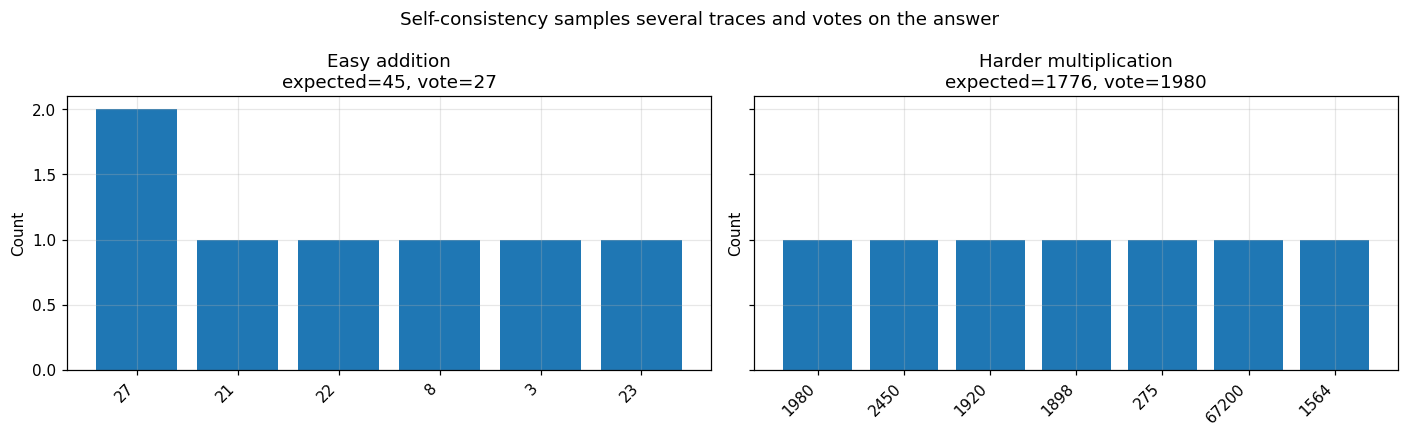

In [8]:
import re

cot_example = "Q: What is 12 + 15?\nA: Let's think step by step. 12 + 15 = 12 + 10 + 5 = 22 + 5 = 27. Therefore the answer is 27.\n\n"

tasks = [
    {"label": "Easy addition", "question": "What is 17 + 28?", "expected": 45, "max_new_tokens": 24},
    {"label": "Harder multiplication", "question": "What is 37 * 48?", "expected": 1776, "max_new_tokens": 40},
]

n_samples = 7
temperature = 0.8
top_p = 0.95


def reasoning_prompt(question):
    return cot_example + f"Q: {question}\nA: Let's think step by step."


def generate_trace(prompt, max_new_tokens, sample=False, seed=42):
    encoded = tokenizer(prompt, return_tensors="pt")

    kwargs = {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.eos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "do_sample": sample,
    }

    if sample:
        torch.manual_seed(seed)
        kwargs["temperature"] = temperature
        kwargs["top_p"] = top_p

    with torch.no_grad():
        output = model_base.generate(**kwargs)

    continuation = output[0, encoded["input_ids"].shape[1] :]
    return tokenizer.decode(continuation, skip_special_tokens=True).strip()


def clean_trace(text):
    text = re.split(r"(?:\n+|\s+)Q:\s", text, maxsplit=1)[0]
    text = re.sub(r"\s+Q:?$", "", text)
    return text.strip()


def extract_last_integer(text):
    matches = re.findall(r"-?\d+", text.replace(",", ""))
    return int(matches[-1]) if matches else None


results = []

for task in tasks:
    prompt = reasoning_prompt(task["question"])

    greedy_trace = clean_trace(generate_trace(prompt, task["max_new_tokens"], sample=False))
    greedy_answer = extract_last_integer(greedy_trace)

    sampled = []
    for i in range(n_samples):
        trace = clean_trace(generate_trace(prompt, task["max_new_tokens"], sample=True, seed=42 + i))
        answer = extract_last_integer(trace)
        sampled.append({"trace": trace, "answer": answer if answer is not None else "no-parse"})

    counts = Counter(row["answer"] for row in sampled)
    majority_answer, majority_count = counts.most_common(1)[0]
    agreement = majority_count / n_samples

    results.append(
        {
            "task": task["label"],
            "question": task["question"],
            "expected": task["expected"],
            "greedy_answer": greedy_answer,
            "sampled": sampled,
            "counts": counts,
            "majority_answer": majority_answer,
            "agreement": agreement,
        }
    )

    print(task["label"])
    print(f"Question: {task['question']}")
    print(f"Expected answer: {task['expected']}")
    print(f"Greedy answer: {greedy_answer}")
    print(f"Majority-vote answer: {majority_answer}  agreement={agreement:.0%}")
    print("First three sampled traces:")

    for row in sampled[:3]:
        trace = " ".join(row["trace"].split())
        if len(trace) > 120:
            trace = trace[:117] + "..."
        print(f"  answer={row['answer']}: {trace}")

    print()

fig, axes = plt.subplots(1, len(results), figsize=(13, 4), sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    items = result["counts"].most_common()
    labels = [str(answer) for answer, _ in items]
    values = [count for _, count in items]

    ax.bar(range(len(labels)), values)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Count")
    ax.set_title(f"{result['task']}\nexpected={result['expected']}, vote={result['majority_answer']}")

fig.suptitle("Self-consistency samples several traces and votes on the answer")
plt.tight_layout()
plt.show()

# Prompt Fragility

The examples above might make prompt engineering look precise and stable. It isn't. Prompts are brittle, and the failure modes are worth naming plainly.

| Fragility | Example | Why it happens |
|-----------|---------|---------------|
| **Order sensitivity** | Swapping the order of few-shot examples changes the answer | Recency bias in attention; later tokens have stronger causal influence |
| **Format sensitivity** | Adding or removing a newline changes classification accuracy | Tokenizer splits change, altering the hidden-state trajectory |
| **Label sensitivity** | Using "positive/negative" vs "good/bad" changes ICL accuracy | Different tokens activate different pretraining associations |
| **Instruction fragility** | "Classify the sentiment" vs "What is the sentiment?" | Slight rephrasing shifts which pretraining distribution is matched |
| **Majority label bias** | If most few-shot examples are positive, the model predicts positive | The model infers a base-rate from the context |

Min et al. (2022) showed a striking result: in many ICL settings, the *format and label space* of the examples matter more than the *correctness* of the labels. The model is often learning the task structure from the prompt template, not from the input-output mapping.

What usually helps in practice:

- **Ensemble over prompt variants**: run the same query with different wordings and aggregate.
- **Calibrate**: measure the model's prior bias on a neutral prompt, then subtract it.
- **Structured output**: constrain the output format (for example JSON schema) to reduce ambiguity.
- **Few-shot with balanced labels**: ensure the example set does not introduce a majority-class bias.
- **Temperature > 0 + self-consistency**: diversity across samples can compensate for prompt-level fragility.

Prompt engineering is not a substitute for evaluation. A prompt that works on five examples may fail on the sixth. Without a proper evaluation loop, you are optimising in the dark.

A prompt is a model artifact, so it needs to be treated as one.

Once you start changing prompts, you need the same discipline you would use for any other model component: fixed task definitions, held-out cases, clear metrics, cost tracking, and regression checks. A compact evaluation loop should track:

1. **Task definition**: prevents prompt drift and hidden target changes.
2. **Test set**: separates genuine improvement from cherry-picked wins.
3. **Scoring metric**: makes tradeoffs explicit, whether accuracy, F1, pass@k, or judge agreement.
4. **Failure categories**: show where the prompt breaks, not just how often.
5. **Cost and latency**: keep reasoning-token and self-consistency gains grounded in runtime reality.
6. **Regression tests**: catch backsliding when you tweak wording, examples, or tool instructions.

Without that loop, you are testing in the dark, and prompt iteration quickly becomes anecdotal. You remember the good examples and miss the quiet failures.

Once prompting starts to touch tools or external state, the failure surface widens. The table below summarises the main failure modes and the controls that matter most.

| Failure | Root Cause | Mitigation |
|---------|-----------|------------|
| **Prompt injection** | Model cannot reliably separate data from instructions in untrusted input | Capability controls: tool allowlists, least-privilege credentials, output validation, retrieval isolation, human approval for irreversible actions, and audit logs |
| **Hallucinated reasoning** | CoT trace is fluent but factually wrong | Verification, self-consistency, grounding |
| **Faithfulness gap** | Stated reasoning does not reflect actual computation | Mechanistic interpretability, probing |
| **Context overflow** | Long prompts push critical information beyond attention span | Chunking, retrieval-augmented generation |
| **Format collapse** | Overconstrained prompts cause the model to produce degenerate output | Relax constraints, increase temperature |

Prompt injection is not solved by better wording alone. Once the model can call tools or act on external systems, the real defences live in capability controls and verification around the model.

# References

1. Brown, T., Mann, B., Ryder, N., et al. (2020). *Language Models are Few-Shot Learners*. [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)
2. Wei, J., Wang, X., Schuurmans, D., et al. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*. [arXiv:2201.11903](https://arxiv.org/abs/2201.11903)
3. Kojima, T., Gu, S. S., Reid, M., et al. (2022). *Large Language Models are Zero-Shot Reasoners*. [arXiv:2205.11916](https://arxiv.org/abs/2205.11916)
4. Wang, X., Wei, J., Schuurmans, D., et al. (2022). *Self-Consistency Improves Chain of Thought Reasoning in Language Models*. [arXiv:2203.11171](https://arxiv.org/abs/2203.11171)
5. Zelikman, E., Wu, Y., Mu, J., et al. (2022). *STaR: Bootstrapping Reasoning With Reasoning*. [arXiv:2203.14465](https://arxiv.org/abs/2203.14465)
6. Cobbe, K., Kosaraju, V., Bavarian, M., et al. (2021). *Training Verifiers to Solve Math Word Problems*. [arXiv:2110.14168](https://arxiv.org/abs/2110.14168)
7. Lightman, H., Kosaraju, V., Burda, Y., et al. (2023). *Let's Verify Step by Step*. [arXiv:2305.20050](https://arxiv.org/abs/2305.20050)
8. Turpin, M., Michael, J., Perez, E., et al. (2023). *Language Models Don't Always Say What They Think: Unfaithful Explanations in Chain-of-Thought Prompting*. [arXiv:2305.04388](https://arxiv.org/abs/2305.04388)
9. Yao, S., Yu, D., Zhao, J., et al. (2023). *Tree of Thoughts: Deliberate Problem Solving with Large Language Models*. [arXiv:2305.10601](https://arxiv.org/abs/2305.10601)
10. Yao, S., Zhao, J., Yu, D., et al. (2022). *ReAct: Synergizing Reasoning and Acting in Language Models*. [arXiv:2210.03629](https://arxiv.org/abs/2210.03629)
11. Olsson, C., Elhage, N., Nanda, N., et al. (2022). *In-context Learning and Induction Heads*. [arXiv:2209.11895](https://arxiv.org/abs/2209.11895)
12. Min, S., Lyu, X., Holtzman, A., et al. (2022). *Rethinking the Role of Demonstrations: What Makes In-Context Learning Work?* [arXiv:2202.12837](https://arxiv.org/abs/2202.12837)
13. Zelikman, E., Harik, G., Shao, Y., et al. (2024). *Quiet-STaR: Language Models Can Teach Themselves to Think Before Speaking*. [arXiv:2403.09629](https://arxiv.org/abs/2403.09629)
14. DeepSeek-AI, Guo, D., Yang, D., et al. (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. [arXiv:2501.12948](https://arxiv.org/abs/2501.12948)
15. Jurafsky, D. & Martin, J. H. (2026). *Speech and Language Processing*, 3rd ed. draft. [web.stanford.edu/~jurafsky/slp3/](https://web.stanford.edu/~jurafsky/slp3/)
16. Allal, L. B., Lozhkov, A., Penedo, G., et al. (2025). *SmolLM2: When Smol Goes Big*. [arXiv:2502.02737](https://arxiv.org/abs/2502.02737)

GitHub repository: [here](https://github.com/adamd1985/quant_research/blob/main/prompt_engineering_how_it_works.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/how-prompt-engineering-works)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.
